In [1]:
import os 
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch as ts
import torch.nn as nn
from sklearn.metrics import confusion_matrix , classification_report

device = ts.device("cuda")

In [ ]:
from torchvision.transforms import transforms

trans = transforms.Compose([
    transforms.ToTensor(),# image to tensor -> scale(0,1)
    transforms.Normalize((0.5 , 0.5 , 0.5 ) , (0.5 , 0.5 , 0.5 )) # set of values for normalizing( -1 , 1)
]) 

from torchvision.datasets import CIFAR10

traindata = CIFAR10(root="./base task" , train=True , download= True , transform=trans)
testdata = CIFAR10(root="./base task" , train=False , download= True , transform=trans)

from torch.utils.data import DataLoader

train_x = DataLoader( traindata, batch_size =  64 , shuffle = True)
test_x = DataLoader(testdata , batch_size=64 )

Files already downloaded and verified
Files already downloaded and verified


In [8]:
# Residual block 

class resblock(nn.Module):

    def __init__(self , in_channel , out_channel , stride):
        
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=in_channel , out_channels=out_channel , kernel_size=3 , padding=1 , stride=stride)

        self.relu = nn.ReLU()

        self.conv2 = nn.Conv2d(in_channels=out_channel , out_channels=out_channel , kernel_size=3 , padding=1 )
        self.bn1 = nn.BatchNorm2d(out_channel)
        self.bn2 = nn.BatchNorm2d(out_channel)

        if stride != 1 or in_channel != out_channel :

            self.shortcut = nn.Sequential(

                nn.Conv2d(
                    in_channels=in_channel,
                    out_channels=out_channel,
                    kernel_size=1,
                    stride=stride
                ),
                nn.BatchNorm2d(out_channel)

            )
        else :

            self.shortcut = nn.Identity()
    
    def forward(self , x):

        out = self.relu(self.bn1(self.conv1(x)))  # Conv1 -> bn > relu
        out = self.bn2(self.conv2(out)) # conv2 -> bn 
        out = out + self.shortcut(x) # adding skip connectionn 

        out = self.relu(out) # final relu

        return out 

In [9]:
class cumtomresnet(nn.Module):

    def __init__(self, f_out = 10):
        super().__init__()

        self.start = nn.Sequential(
            nn.Conv2d(
                3 , 64 ,
                kernel_size=3 ,
                stride=1 , 
                padding= 1
            ),
            nn.BatchNorm2d(64) , 
            nn.ReLU()
        )

        self.stage_1 = nn.Sequential(
            resblock(64 , 64 , stride = 1),
            resblock(64 , 64 , stride = 1)
        )

        self.stage_2 = nn.Sequential(
            resblock(64 , 128 , stride = 2 ),
            resblock(128 , 128 , stride= 1)
        )

        self.stage_3 = nn.Sequential(
            resblock(128 , 256 , stride = 2),
            resblock(256 , 256 , stride = 1)
        )

        self.relu = nn.ReLU()

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.linear = nn.Linear(256 , f_out)

    def forward(self , x ):

        x = self.start(x)
        x = self.stage_1(x)
        x = self.stage_2(x)
        x = self.stage_3(x)
        x = self.pool(x)
        x = x.view(x.size(0) , -1)
        x = self.linear(x)

        return x 
    
model = cumtomresnet().to(device)
critirian = nn.CrossEntropyLoss()
optim = ts.optim.Adam(model.parameters())

In [13]:
epochs = 25
best_model = float("inf")
train_loss = []
val_loss  = []

for epoch in range(epochs):

    model.train()
    running_losses = 0.00

    for image , label in train_x:
        image = image.to(device)
        label = label.to(device)

        optim.zero_grad()
        outputs = model(image)
        loss = critirian(outputs , label)
        loss.backward()
        optim.step()

        running_losses += loss.item()
    
    epoch_losses = running_losses/len(train_x)
    train_loss.append(epoch_losses)

    model.eval()
    total =0 
    correct = 0 

    all_preds, all_labels = [], []
    with ts.no_grad():

        running_val_losses = 0.00
        for image , label in test_x:

            image , label = image.to(device), label.to(device)

            output = model(image)
            loss  = critirian(output , label)
            running_val_losses += loss.item()

            _ , pred = ts.max(output , 1)
            correct += (label == pred).sum().item()
            total += label.size(0)

            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

            #print(classification_report(all_labels, all_preds, target_names=traindata.classes))
            # Check if this epoch is better than previous best
        accuracy = 100 * correct/total
        epoch_val_loss = running_val_losses/len(test_x)
        val_loss.append(epoch_val_loss)
        if epoch_val_loss < best_model:
            best_model = epoch_val_loss
            ts.save(model.state_dict(), "best_model.pth")
            print("Best model updated and saved!")

        
        
        print(f"""epoch {1+epoch} : train_loss = {epoch_losses} & test_loss = {epoch_val_loss}
               $$ accuracy : {accuracy} """)

Best model updated and saved!
epoch 1 : train_loss = 0.04398615589859534 & test_loss = 0.8201476812362671
               $$ accuracy : 82.9 
Best model updated and saved!
epoch 2 : train_loss = 0.03259753506174501 & test_loss = 0.6769906304776668
               $$ accuracy : 85.56 
epoch 3 : train_loss = 0.011859194563858554 & test_loss = 0.6898556992411613
               $$ accuracy : 86.47 
epoch 4 : train_loss = 0.005312469432710157 & test_loss = 0.7394171044230461
               $$ accuracy : 86.01 
epoch 5 : train_loss = 0.004693269725456568 & test_loss = 0.7529272168874741
               $$ accuracy : 85.93 
epoch 6 : train_loss = 0.020042663922845812 & test_loss = 1.2456804782152175
               $$ accuracy : 78.81 
epoch 7 : train_loss = 0.0554990241760198 & test_loss = 0.7785339988768101
               $$ accuracy : 83.99 
epoch 8 : train_loss = 0.024728787447591976 & test_loss = 0.7057436808943749
               $$ accuracy : 85.84 
epoch 9 : train_loss = 0.0110594261478043

THIS BELOW ONE { batch size = 256 : tested for faster computation}

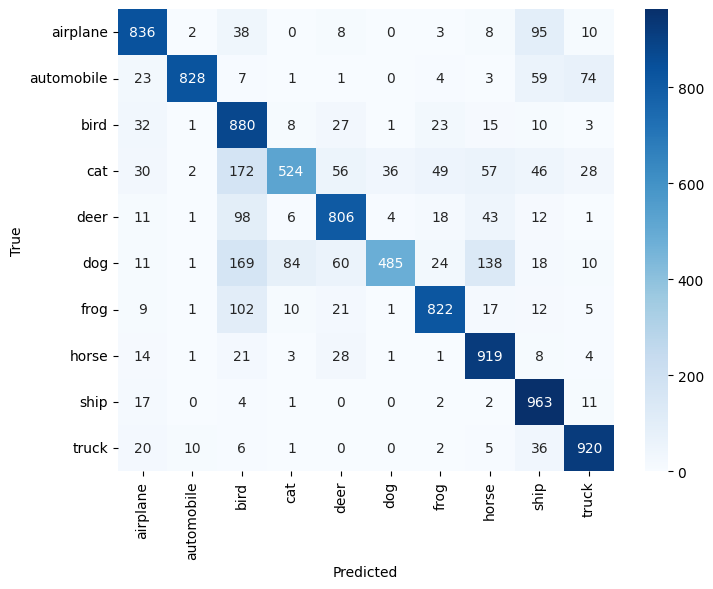

              precision    recall  f1-score   support

    airplane       0.83      0.84      0.83      1000
  automobile       0.98      0.83      0.90      1000
        bird       0.59      0.88      0.70      1000
         cat       0.82      0.52      0.64      1000
        deer       0.80      0.81      0.80      1000
         dog       0.92      0.48      0.63      1000
        frog       0.87      0.82      0.84      1000
       horse       0.76      0.92      0.83      1000
        ship       0.76      0.96      0.85      1000
       truck       0.86      0.92      0.89      1000

    accuracy                           0.80     10000
   macro avg       0.82      0.80      0.79     10000
weighted avg       0.82      0.80      0.79     10000



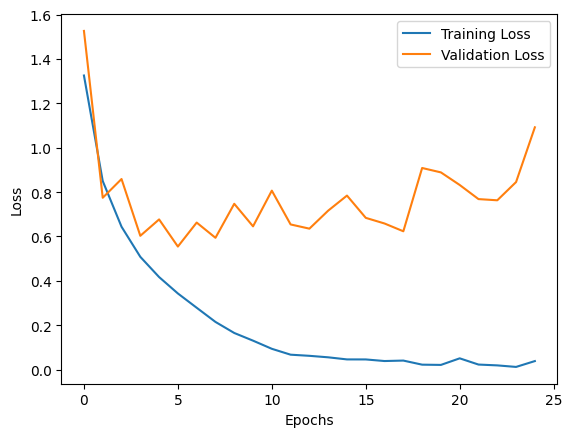

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=traindata.classes,
            yticklabels=traindata.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# classificaation report

print(classification_report(
    all_labels,
    all_preds,
    target_names=traindata.classes
))

# Loss curves

plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


THIS BELOW ONE { batch size = 64 : tested for faster computation}

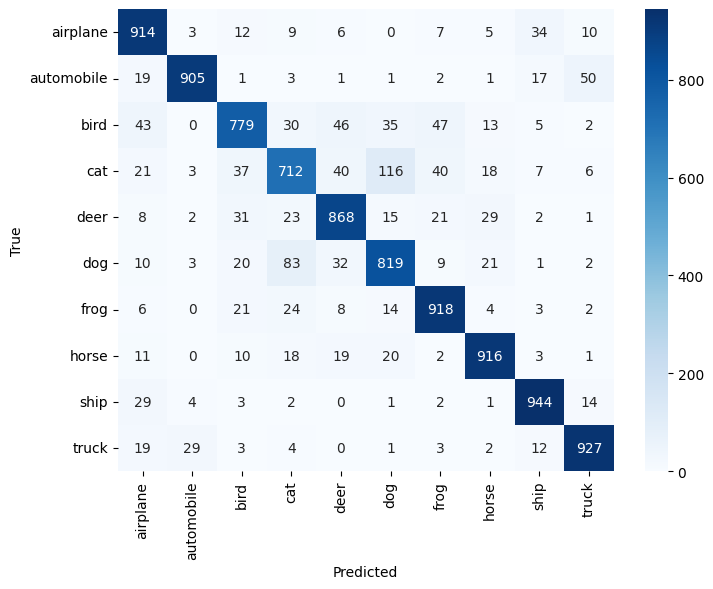

              precision    recall  f1-score   support

    airplane       0.85      0.91      0.88      1000
  automobile       0.95      0.91      0.93      1000
        bird       0.85      0.78      0.81      1000
         cat       0.78      0.71      0.75      1000
        deer       0.85      0.87      0.86      1000
         dog       0.80      0.82      0.81      1000
        frog       0.87      0.92      0.90      1000
       horse       0.91      0.92      0.91      1000
        ship       0.92      0.94      0.93      1000
       truck       0.91      0.93      0.92      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



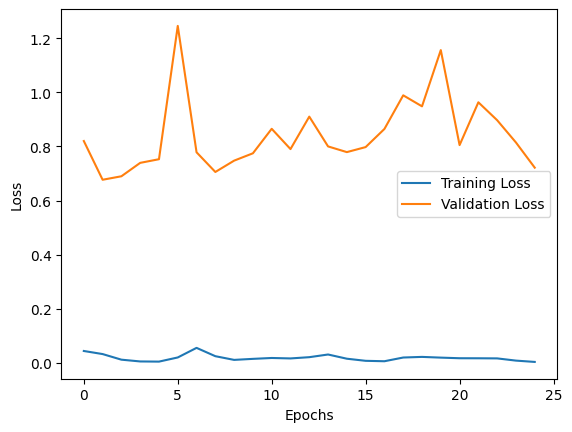

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=traindata.classes,
            yticklabels=traindata.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# classificaation report

print(classification_report(
    all_labels,
    all_preds,
    target_names=traindata.classes
))

# Loss curves

plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(
    all_labels,
    all_preds,
    average="weighted"
)

recall = recall_score(
    all_labels,
    all_preds,
    average="weighted"
)

f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted"
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Precision : 0.8698
Recall    : 0.8702
F1 Score  : 0.8694


Brief Explanation of Architecture Choices

The model was designed using a custom ResNet architecture to improve feature learning while avoiding the degradation problem that occurs in deeper convolutional neural networks. Residual connections allow the network to learn residual mappings instead of directly learning the desired transformation, making optimization easier and improving gradient flow.

The architecture begins with a 3×3 convolutional layer with 64 filters, followed by Batch Normalization and ReLU activation to extract low-level image features. Three residual stages are then used:

Stage 1: Two residual blocks with 64 channels preserve the spatial resolution while learning basic features.
Stage 2: The first residual block downsamples the feature maps using stride 2 and increases the number of channels from 64 to 128, allowing the model to learn more complex representations.
Stage 3: Another downsampling stage increases the channels from 128 to 256 for high-level feature extraction.

Whenever the spatial dimensions or number of channels change, a 1×1 projection shortcut is used to match the dimensions before residual addition.

Batch Normalization is applied after each convolution to stabilize training and accelerate convergence, while ReLU introduces non-linearity and helps mitigate the vanishing gradient problem.

Instead of large fully connected layers, the model uses Adaptive Average Pooling to reduce each feature map to a single value, significantly reducing the number of parameters and helping prevent overfitting. A final fully connected layer maps the extracted features to the 10 CIFAR-10 classes.

The model was trained using the Adam optimizer with Cross-Entropy Loss, which is well suited for multi-class image classification task